In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import kurtosis
from scipy.fft import fft
from scipy.signal import welch

In [4]:
directories_ciss = ["C:\\Users\\germa\\Downloads\\RF_Project\\data\\raw\\Worn_tool_no1_pattern1\\CISSRawData_LogFiles","C:\\Users\\germa\\Downloads\\RF_Project\\data\\raw\\Worn_tool_no2_pattern2\\CISSRawData_LogFiles",
                    "C:\\Users\\germa\\Downloads\\RF_Project\\data\\raw\\Good_tool_no1_pattern4\\CISSRawData_LogFiles"]
directories_registry = ["C:\\Users\\germa\\Downloads\\RF_Project\\data\\raw\\Worn_tool_no1_pattern1", "C:\\Users\\germa\\Downloads\\RF_Project\\data\\raw\\Worn_tool_no2_pattern2",  
                        "C:\\Users\\germa\\Downloads\\RF_Project\\data\\raw\\Good_tool_no1_pattern4"]

val_directories_ciss = ["C:\\Users\\germa\\Downloads\\RF_Project\\data\\raw\\Worn_tool_no3_pattern3\\CISSRawData_LogFiles", "C:\\Users\\germa\\Downloads\\RF_Project\\data\\raw\\Good_tool_no2_pattern5\\CISSRawData_LogFiles"]
val_directories_registry = ["C:\\Users\\germa\\Downloads\\RF_Project\\data\\raw\\Worn_tool_no3_pattern3", "C:\\Users\\germa\\Downloads\\RF_Project\\data\\raw\\Good_tool_no2_pattern5"]

In [7]:
def get_ciss_raw(directory):
    dataframes = []
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path, skiprows=8, encoding='Windows-1252')
            df = df.iloc[:-1]  # Remove the last row
            df.rename(columns={"Unix TimeStamp (ms)": "TimeStamp", "Data / x_axis": "x_axis"}, inplace=True)
            df["TimeStamp"] = pd.to_numeric(df["TimeStamp"]).astype(float)
            df.drop(columns=["Measurement Type"], inplace=True)
            if "Worn" in directory:
                df["Label"] = 1
            elif "Good" in directory:
                df["Label"] = 0
             # Initialize good tool with the value 0
            dataframes.append(df)
    df = pd.concat(dataframes)
    return df

In [9]:
def get_registry_record(directory):
    dataframes = []
    for filename in os.listdir(directory):
        if filename.endswith(".csv"):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            df.rename(columns={"Unnamed: 0": "TimeStamp"}, inplace=True)
            df["TimeStamp"] = df["TimeStamp"].astype(str).str.replace(".", "", regex=False).str[:13]
            df["TimeStamp"] = pd.to_numeric(df["TimeStamp"]).astype(float)
            df.drop(columns=["WinPCNCRunning", "CurrentJobProgress", "CurrentJobTimeMin", "CurrentJobTimeSec", "CurrentJobCommandNo", "CurrentSpdOvr", "State"], inplace=True)
            dataframes.append(df)
    df = pd.concat(dataframes)
    return df

In [11]:
dataframes_ciss = []
for directory in directories_ciss:
    dataframes_ciss.append(get_ciss_raw(directory))

In [13]:
dataframes_ciss

[         TimeStamp  x_axis  y_axis  z_axis  Label
 0     1.733408e+12    19.0  -993.0     0.0      1
 1     1.733408e+12    11.0  -991.0     1.0      1
 2     1.733408e+12    19.0  -995.0     0.0      1
 3     1.733408e+12    19.0  -993.0     3.0      1
 4     1.733408e+12    11.0  -993.0     0.0      1
 ...            ...     ...     ...     ...    ...
 6626  1.733410e+12    11.0  -991.0    -1.0      1
 6627  1.733410e+12    21.0  -995.0     0.0      1
 6628  1.733410e+12    11.0  -997.0    -3.0      1
 6629  1.733410e+12    15.0  -987.0     5.0      1
 6630  1.733410e+12    13.0  -985.0     7.0      1
 
 [2381631 rows x 5 columns],
           TimeStamp  x_axis  y_axis  z_axis  Label
 0      1.733410e+12     7.0  -991.0     9.0      1
 1      1.733410e+12    19.0  -995.0    -1.0      1
 2      1.733410e+12    29.0  -985.0     7.0      1
 3      1.733410e+12     9.0  -989.0     3.0      1
 4      1.733410e+12     1.0  -987.0     7.0      1
 ...             ...     ...     ...     ... 

In [15]:
dataframes_registry = []
for directory in directories_registry:
    dataframes_registry.append(get_registry_record(directory))

In [17]:
dataframe_ciss = pd.concat(dataframes_ciss)
dataframe_ciss = dataframe_ciss.sort_values("TimeStamp", ascending=True)
dataframe_registry = pd.concat(dataframes_registry)
dataframe_registry = dataframe_registry.sort_values("TimeStamp", ascending=True)

In [19]:
dataframe_all = pd.merge_asof(dataframe_ciss, dataframe_registry, on="TimeStamp", direction="nearest")

In [21]:
dataframe_all

,TimeStamp,x_axis,y_axis,z_axis,Label,Pos_X,Pos_Y,Pos_Z
0,1.733408e+12,19.0,-993.0,0.0,1,31975.0,231487.0,0.0
1,1.733408e+12,21.0,-989.0,0.0,1,31975.0,231487.0,0.0
2,1.733408e+12,11.0,-985.0,7.0,1,31975.0,231487.0,0.0
3,1.733408e+12,23.0,-989.0,-1.0,1,31975.0,231487.0,0.0
4,1.733408e+12,13.0,-993.0,1.0,1,31975.0,231487.0,0.0
...,...,...,...,...,...,...,...,...
7188824,1.733414e+12,23.0,-987.0,7.0,0,176575.0,262987.0,6062.0
7188825,1.733414e+12,19.0,-997.0,-1.0,0,176575.0,262987.0,6062.0
7188826,1.733414e+12,29.0,-993.0,7.0,0,176575.0,262987.0,6062.0
7188827,1.733414e+12,11.0,-997.0,7.0,0,176575.0,262987.0,6062.0


In [23]:
val_dataframes_ciss = []
for directory in val_directories_ciss:
    val_dataframes_ciss.append(get_ciss_raw(directory))

In [24]:
val_dataframes_ciss

[         TimeStamp  x_axis  y_axis  z_axis  Label
 0     1.733412e+12    19.0 -1001.0    11.0      1
 1     1.733412e+12    13.0  -997.0     1.0      1
 2     1.733412e+12    25.0  -989.0     7.0      1
 3     1.733412e+12    29.0 -1001.0     1.0      1
 4     1.733412e+12    17.0  -995.0     0.0      1
 ...            ...     ...     ...     ...    ...
 3146  1.733413e+12    21.0  -991.0     5.0      1
 3147  1.733413e+12    15.0  -997.0    15.0      1
 3148  1.733413e+12     7.0  -999.0    -7.0      1
 3149  1.733413e+12    13.0  -993.0     0.0      1
 3150  1.733413e+12    13.0  -991.0     0.0      1
 
 [2453151 rows x 5 columns],
          TimeStamp  x_axis  y_axis  z_axis  Label
 0     1.733415e+12    17.0 -1003.0    -3.0      0
 1     1.733415e+12    19.0  -995.0    11.0      0
 2     1.733415e+12    23.0  -999.0     5.0      0
 3     1.733415e+12    15.0  -995.0     3.0      0
 4     1.733415e+12     7.0  -995.0     0.0      0
 ...            ...     ...     ...     ...    ...


In [27]:
val_dataframes_registry = []
for directory in val_directories_registry:
    val_dataframes_registry.append(get_registry_record(directory))

In [29]:
val_dataframe_ciss = pd.concat(val_dataframes_ciss)
val_dataframe_ciss = val_dataframe_ciss.sort_values("TimeStamp", ascending=True)
val_dataframe_registry = pd.concat(val_dataframes_registry)
val_dataframe_registry = val_dataframe_registry.sort_values("TimeStamp", ascending=True)

In [31]:
val_dataframe_all = pd.merge_asof(val_dataframe_ciss, val_dataframe_registry, on="TimeStamp", direction="nearest")

In [33]:
val_dataframe_all

,TimeStamp,x_axis,y_axis,z_axis,Label,Pos_X,Pos_Y,Pos_Z
0,1.733412e+12,19.0,-1001.0,11.0,1,31975.0,231487.0,6062.0
1,1.733412e+12,29.0,-997.0,7.0,1,31975.0,231487.0,6062.0
2,1.733412e+12,19.0,-997.0,-1.0,1,31975.0,231487.0,6062.0
3,1.733412e+12,7.0,-995.0,5.0,1,31975.0,231487.0,6062.0
4,1.733412e+12,17.0,-997.0,9.0,1,31975.0,231487.0,6062.0
...,...,...,...,...,...,...,...,...
5185481,1.733416e+12,19.0,-999.0,0.0,0,31975.0,231487.0,6062.0
5185482,1.733416e+12,15.0,-995.0,9.0,0,31975.0,231487.0,6062.0
5185483,1.733416e+12,15.0,-991.0,17.0,0,31975.0,231487.0,6062.0
5185484,1.733416e+12,33.0,-1001.0,7.0,0,31975.0,231487.0,6062.0


In [35]:
# Delete all the data in TimeStamp where the position of the milling tool was above the metal plate
peak_threshold = 0.975 * dataframe_all["Pos_Z"].max()
dataframe_all = dataframe_all[dataframe_all["Pos_Z"] >= peak_threshold]

val_peak_threshold = 0.975 * val_dataframe_all["Pos_Z"].max()
val_dataframe_all = val_dataframe_all[val_dataframe_all["Pos_Z"] >= peak_threshold]

C:\Users\germa\AppData\Local\Temp\ipykernel_23144\115674131.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_all['TimeStamp'] = pd.to_datetime(dataframe_all['TimeStamp'], unit='ms')
C:\Users\germa\AppData\Local\Temp\ipykernel_23144\115674131.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_dataframe_all['TimeStamp'] = pd.to_datetime(val_dataframe_all['TimeStamp'], unit='ms')
C:\Users\germa\AppData\Local\Temp\ipykernel_23144\115674131.py:10: SettingWithCopyWarning: 
A value is trying to b

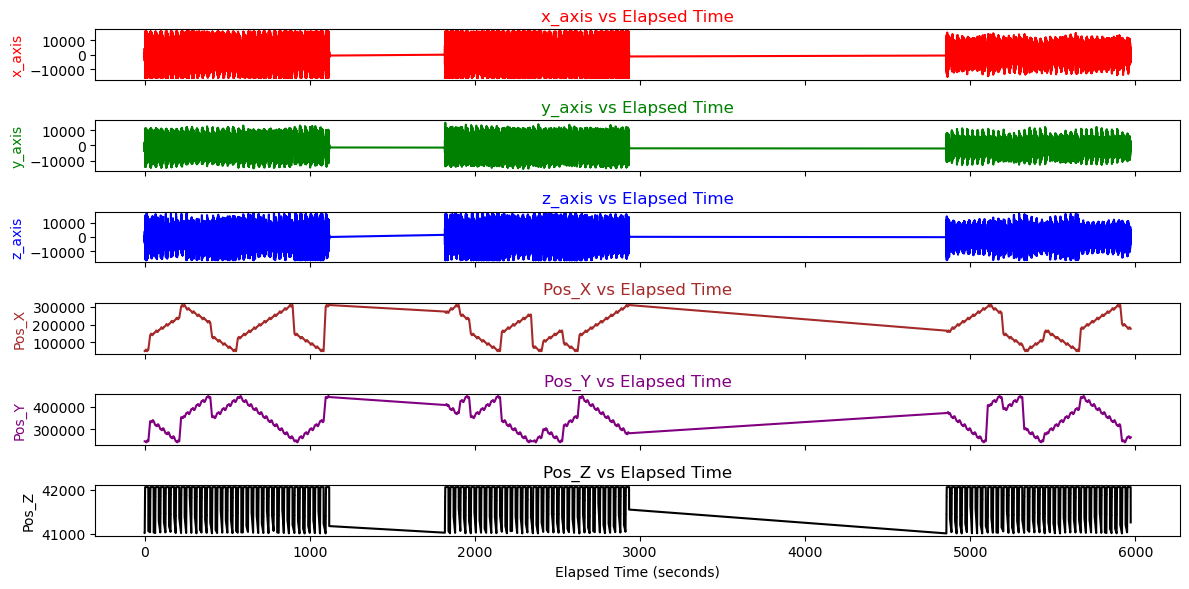

In [37]:
# Convert TimeStamp from numeric to datetime
dataframe_all['TimeStamp'] = pd.to_datetime(dataframe_all['TimeStamp'], unit='ms')

val_dataframe_all['TimeStamp'] = pd.to_datetime(val_dataframe_all['TimeStamp'], unit='ms')

# List of columns to plot
columns_to_plot = ['x_axis', 'y_axis', 'z_axis','Pos_X','Pos_Y','Pos_Z']

# Calculate the elapsed time since the recording started
dataframe_all['Elapsed_Time'] = (dataframe_all['TimeStamp'] - dataframe_all['TimeStamp'].iloc[0]).dt.total_seconds()

val_dataframe_all['Elapsed_Time'] = (val_dataframe_all['TimeStamp'] - val_dataframe_all['TimeStamp'].iloc[0]).dt.total_seconds()

# Plot the data with the elapsed time
fig, axes = plt.subplots(len(columns_to_plot), 1, figsize=(12, 6), sharex=True)
colors = ['red', 'green', 'blue', 'brown', 'purple', 'black']

# Plot each column
for ax, col, color in zip(axes, columns_to_plot, colors):
    ax.plot(dataframe_all['Elapsed_Time'], dataframe_all[col], label=col, color=color)
    ax.set_title(f'{col} vs Elapsed Time', color=color)  # Optional: Title color matches line
    ax.set_ylabel(col, color=color)  # Optional: Y-axis label matches color

# Set common x-axis label
plt.xlabel('Elapsed Time (seconds)')
plt.tight_layout()
plt.show()

In [39]:
dataframe_all.drop(columns=["Pos_X", "Pos_Y", "Pos_Z"], inplace=True)

val_dataframe_all.drop(columns=["Pos_X", "Pos_Y", "Pos_Z"], inplace=True)

C:\Users\germa\AppData\Local\Temp\ipykernel_23144\2166797853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe_all.drop(columns=["Pos_X", "Pos_Y", "Pos_Z"], inplace=True)
C:\Users\germa\AppData\Local\Temp\ipykernel_23144\2166797853.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_dataframe_all.drop(columns=["Pos_X", "Pos_Y", "Pos_Z"], inplace=True)


Mean: -170.9018
Median: -193.0000
Variance: 42150135.7079
Kurtosis: -0.2196
Peak Frequency: 0.0000


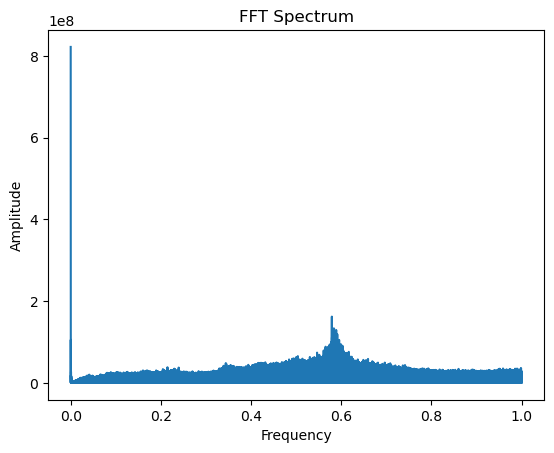

In [41]:
# Statistical metrics
mean = np.mean(dataframe_all['x_axis'])
median = np.median(dataframe_all['x_axis'])
variance = np.var(dataframe_all['x_axis'])
kurt = kurtosis(dataframe_all['x_axis'])


print(f"Mean: {mean:.4f}")
print(f"Median: {median:.4f}")
print(f"Variance: {variance:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# FFT on signal
signal = dataframe_all['x_axis'].to_numpy()  # Convert to NumPy array
N = len(signal)
fft_values = np.abs(fft(signal))[:N // 2]  # Take positive frequencies
frequencies = np.linspace(0, 1, N // 2)  # Frequency range

# Find the peak frequency
peak_freq = frequencies[np.argmax(fft_values)]

print(f"Peak Frequency: {peak_freq:.4f}")

# Plot FFT spectrum
plt.plot(frequencies, fft_values)
plt.title("FFT Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()


Mean: -979.4867
Median: -1001.0000
Variance: 11437036.3932
Kurtosis: 0.8479
Peak Frequency: 0.0000


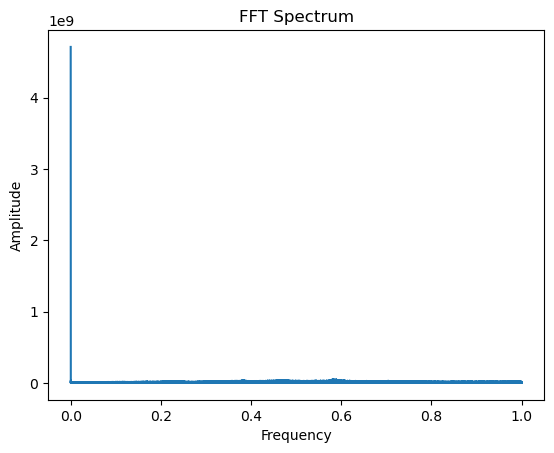

In [43]:
# Statistical metrics
mean = np.mean(dataframe_all['y_axis'])
median = np.median(dataframe_all['y_axis'])
variance = np.var(dataframe_all['y_axis'])
kurt = kurtosis(dataframe_all['y_axis'])


print(f"Mean: {mean:.4f}")
print(f"Median: {median:.4f}")
print(f"Variance: {variance:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# FFT on signal
signal = dataframe_all['y_axis'].to_numpy()  # Convert to NumPy array
N = len(signal)
fft_values = np.abs(fft(signal))[:N // 2]  # Take positive frequencies
frequencies = np.linspace(0, 1, N // 2)  # Frequency range

# Find the peak frequency
peak_freq = frequencies[np.argmax(fft_values)]

print(f"Peak Frequency: {peak_freq:.4f}")

# Plot FFT spectrum
plt.plot(frequencies, fft_values)
plt.title("FFT Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

Mean: 0.3930
Median: 107.0000
Variance: 26060023.5758
Kurtosis: 0.2143
Peak Frequency: 0.5851


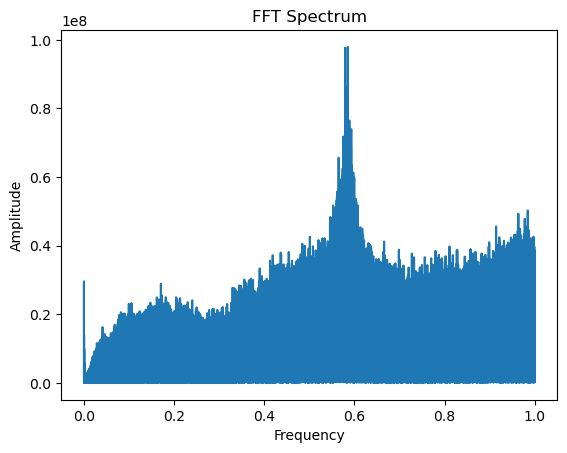

In [44]:
# Statistical metrics
mean = np.mean(dataframe_all['z_axis'])
median = np.median(dataframe_all['z_axis'])
variance = np.var(dataframe_all['z_axis'])
kurt = kurtosis(dataframe_all['z_axis'])


print(f"Mean: {mean:.4f}")
print(f"Median: {median:.4f}")
print(f"Variance: {variance:.4f}")
print(f"Kurtosis: {kurt:.4f}")

# FFT on signal
signal = dataframe_all['z_axis'].to_numpy()  # Convert to NumPy array
N = len(signal)
fft_values = np.abs(fft(signal))[:N // 2]  # Take positive frequencies
frequencies = np.linspace(0, 1, N // 2)  # Frequency range

# Find the peak frequency
peak_freq = frequencies[np.argmax(fft_values)]

print(f"Peak Frequency: {peak_freq:.4f}")

# Plot FFT spectrum
plt.plot(frequencies, fft_values)
plt.title("FFT Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

In [47]:
# Parameters
num_windows = 5400  # Number of desired windows
window_size = len(dataframe_all) // num_windows  # Calculate the window size dynamically
step_size = window_size  # Ensure no overlap between windows

# Create windows
windows = []
for i in range(0, len(dataframe_all), step_size):
    # Check if there's enough data left for a full window
    if i + window_size > len(dataframe_all):
        break
    
    # Extract the window data
    window_data = dataframe_all.iloc[i:i + window_size]
    
    # Calculate features
    features = {
        'x_mean': window_data['x_axis'].mean(),
        'x_std': window_data['x_axis'].std(),
        'x_sum': window_data['x_axis'].sum(),
        'x_median': window_data['x_axis'].median(),
        'y_mean': window_data['y_axis'].mean(),
        'y_std': window_data['y_axis'].std(),
        'y_sum': window_data['y_axis'].sum(),
        'y_median': window_data['y_axis'].median(),
        'z_mean': window_data['z_axis'].mean(),
        'z_std': window_data['z_axis'].std(),
        'z_sum': window_data['z_axis'].sum(),
        'z_median': window_data['z_axis'].median(),
        
        # Add more features as needed
    }
    
    # Assign label based on majority
    label = window_data['Label'].mode()[0]
    features['Label'] = label
     
    windows.append(features)

# Convert to DataFrame
windowed_data = pd.DataFrame(windows)

In [49]:
# Parameters
val_num_windows = 3600  # Number of desired windows
val_window_size = len(val_dataframe_all) // val_num_windows  # Calculate the window size dynamically
val_step_size = val_window_size  # Ensure no overlap between windows

# Create windows
val_windows = []
for i in range(0, len(val_dataframe_all), val_step_size):
    # Check if there's enough data left for a full window
    if i + val_window_size > len(val_dataframe_all):
        break
    
    # Extract the window data
    val_window_data = val_dataframe_all.iloc[i:i + val_window_size]
    
    # Calculate features
    features = {
        'x_mean': val_window_data['x_axis'].mean(),
        'x_std': val_window_data['x_axis'].std(),
        'x_sum': val_window_data['x_axis'].sum(),
        'x_median': val_window_data['x_axis'].median(),
        'y_mean': val_window_data['y_axis'].mean(),
        'y_std': val_window_data['y_axis'].std(),
        'y_sum': val_window_data['y_axis'].sum(),
        'y_median': val_window_data['y_axis'].median(),
        'z_mean': val_window_data['z_axis'].mean(),
        'z_std': val_window_data['z_axis'].std(),
        'z_sum': val_window_data['z_axis'].sum(),
        'z_median': val_window_data['z_axis'].median(),
        
        # Add more features as needed
    }
    
    # Assign label based on majority
    val_label = val_window_data['Label'].mode()[0]
    features['Label'] = val_label
     
    val_windows.append(features)

# Convert to DataFrame
val_windowed_data = pd.DataFrame(val_windows)

In [51]:
windowed_data

,x_mean,x_std,x_sum,x_median,y_mean,y_std,y_sum,y_median,z_mean,z_std,z_sum,z_median,Label
0,-0.196629,1745.398533,-175.0,22.0,-996.473034,1164.439618,-886861.0,-1056.5,3.642697,1380.794059,3242.0,55.0,1
1,-13.230337,1797.108902,-11775.0,58.0,-998.838202,1213.156222,-888966.0,-1080.0,3.874157,1405.578406,3448.0,129.0,1
2,-4.147191,1693.027882,-3691.0,9.0,-1005.369663,1329.661392,-894779.0,-1100.0,-5.728090,1417.965701,-5098.0,69.0,1
3,-5.660674,1714.892402,-5038.0,21.0,-994.339326,1234.185835,-884962.0,-1038.0,1.720225,1373.864111,1531.0,79.5,1
4,2.253933,1826.890824,2006.0,18.0,-1004.379775,1248.814379,-893898.0,-1021.0,0.122472,1581.981154,109.0,101.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5397,-25.939326,2103.733885,-23086.0,-117.0,-1003.094382,1272.875761,-892754.0,-1182.0,11.738202,1683.347628,10447.0,-259.0,0
5398,-25.941573,1666.983321,-23088.0,13.0,-999.414607,1231.070652,-889479.0,-1055.0,12.811236,1447.824426,11402.0,-105.0,0
5399,-0.849438,1339.738157,-756.0,77.0,-999.034831,1103.314013,-889141.0,-1123.0,8.319101,1185.728819,7404.0,-98.0,0
5400,-3.513483,996.989467,-3127.0,83.0,-999.032584,844.709535,-889139.0,-1100.0,7.084270,820.411401,6305.0,-70.0,0


In [53]:
val_windowed_data

,x_mean,x_std,x_sum,x_median,y_mean,y_std,y_sum,y_median,z_mean,z_std,z_sum,z_median,Label
0,-1.371910,1396.688342,-1221.0,-55.0,-1002.041573,1013.871540,-891817.0,-1017.5,4.104494,1378.343070,3653.0,-3.0,1
1,-3.019101,1298.114038,-2687.0,-23.0,-1001.332584,990.240329,-891186.0,-1057.5,9.573034,1340.666845,8520.0,58.0,1
2,1.155056,1411.175121,1028.0,-35.0,-1007.157303,1016.380835,-896370.0,-1006.0,2.283146,1284.302995,2032.0,-74.0,1
3,-4.306742,1361.970762,-3833.0,-68.0,-988.679775,1000.497114,-879925.0,-1016.0,7.761798,1226.647799,6908.0,-5.0,1
4,-13.039326,2012.990694,-11605.0,-81.5,-997.728090,1222.017527,-887978.0,-1018.0,0.948315,1940.890018,844.0,41.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3596,-8.992135,1738.106238,-8003.0,105.0,-999.620225,1323.637459,-889662.0,-1304.0,-8.826966,3073.613762,-7856.0,102.0,0
3597,-4.567416,1284.004463,-4065.0,75.0,-995.777528,1129.406662,-886242.0,-1221.0,7.947191,2284.198100,7073.0,56.0,0
3598,-0.517978,937.096304,-461.0,121.5,-998.013483,851.680000,-888232.0,-1137.0,2.220225,1421.907363,1976.0,-5.5,0
3599,-5.001124,766.375185,-4451.0,19.0,-996.287640,714.809919,-886696.0,-1116.0,5.419101,888.980106,4823.0,12.0,0


In [55]:
windowed_data.to_csv("RF_test_train.csv")

In [57]:
val_windowed_data.to_csv("RF_validation.csv")